In [26]:
import os
import numpy as np
from PIL import Image,ImageEnhance
import random

# keras 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense,Flatten,Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

LOADING DATASET

In [27]:
train_dir = 'C:/Users/Hp/OneDrive/Desktop/Deep learning/MRI images/Training'
test_dir = 'C:/Users/Hp/OneDrive/Desktop/Deep learning/MRI images/Testing'

train_labels = []
train_paths = []

for labels in os.listdir(train_dir):
    for images in os.listdir(os.path.join(train_dir,labels)):
        train_paths.append(os.path.join(train_dir,labels,images))
        train_labels.append(labels)
        # print(images)
train_paths,train_labels = shuffle(train_paths,train_labels)
train_paths


test_labels = []
test_paths = []

for labels in os.listdir(test_dir):
    for images in os.listdir(os.path.join(test_dir,labels)):
        test_paths.append(os.path.join(test_dir,labels,images))
        test_labels.append(labels)
        # print(images)
test_paths,test_labels = shuffle(test_paths,test_labels)
test_paths

['C:/Users/Hp/OneDrive/Desktop/Deep learning/MRI images/Testing\\meningioma\\Te-me_206.jpg',
 'C:/Users/Hp/OneDrive/Desktop/Deep learning/MRI images/Testing\\notumor\\Te-no_135.jpg',
 'C:/Users/Hp/OneDrive/Desktop/Deep learning/MRI images/Testing\\glioma\\Te-gl_101.jpg',
 'C:/Users/Hp/OneDrive/Desktop/Deep learning/MRI images/Testing\\meningioma\\Te-me_52.jpg',
 'C:/Users/Hp/OneDrive/Desktop/Deep learning/MRI images/Testing\\glioma\\Te-gl_390.jpg',
 'C:/Users/Hp/OneDrive/Desktop/Deep learning/MRI images/Testing\\notumor\\Te-no_308.jpg',
 'C:/Users/Hp/OneDrive/Desktop/Deep learning/MRI images/Testing\\meningioma\\Te-me_172.jpg',
 'C:/Users/Hp/OneDrive/Desktop/Deep learning/MRI images/Testing\\pituitary\\Te-pi_181.jpg',
 'C:/Users/Hp/OneDrive/Desktop/Deep learning/MRI images/Testing\\meningioma\\Te-me_96.jpg',
 'C:/Users/Hp/OneDrive/Desktop/Deep learning/MRI images/Testing\\meningioma\\Te-me_287.jpg',
 'C:/Users/Hp/OneDrive/Desktop/Deep learning/MRI images/Testing\\notumor\\Te-no_297.jpg

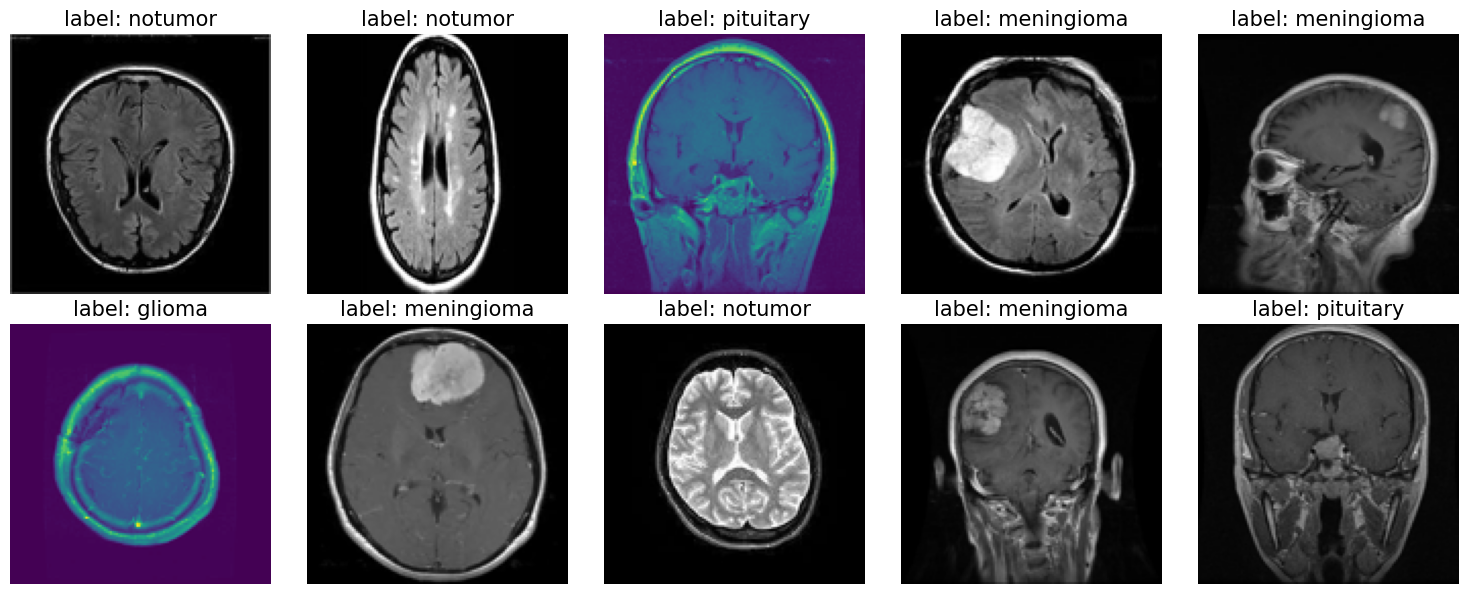

In [28]:
import matplotlib.pyplot as plt

random_indices = random.sample(range(len(train_paths)),10)

fig,axes = plt.subplots(2,5,figsize=(15,6))
axes = axes.ravel()

for i,idx in enumerate(random_indices):
    # print(i,idx)
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((128,128))
    axes[i].imshow(img)
    axes[i].set_title(f"label: {train_labels[idx]}",fontsize=15)
    
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [29]:
# Image agumentation function
def agument_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8,1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8,1.2))
    image = np.array(image)/255.0
    return image

# Load image and apply agumentation
def open_images(paths):
    images = []
    for path in paths:
        img = load_img(path,target_size=(IMAGE_SIZE,IMAGE_SIZE))
        img = agument_image(img)
        images.append(img)
    return np.array(images)


# Encode labels(convert label names to integer)
def encode_labels(labels):
    unique_labels = os.listdir(train_dir)
    return [unique_labels.index(label) for label in labels]

# data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # returns np.array
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_labels(batch_labels)
            yield np.array(batch_images), np.array(batch_labels)

In [30]:
# Model architecture

IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE,IMAGE_SIZE,3),include_top=False,weights='imagenet')

# Freeze all layers of VGG16 model
for layer in base_model.layers:
    layer.trainable = False

base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE,IMAGE_SIZE,3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(len(os.listdir(train_dir)),activation='softmax'))

# Compile model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths)/batch_size)
epochs = 5

# train model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)


model.save("C:/Users/Hp/OneDrive/Desktop/Deep learning/mri_model.h5")



Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 232s 825ms/step - accuracy: 0.8232 - loss: 0.4655
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 223s 796ms/step - accuracy: 0.9089 - loss: 0.2404
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 223s 798ms/step - accuracy: 0.9405 - loss: 0.1578
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 225s 803ms/step - accuracy: 0.9563 - loss: 0.1230
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 223s 795ms/step - accuracy: 0.9673 - loss: 0.0886


loss and accuracy plot

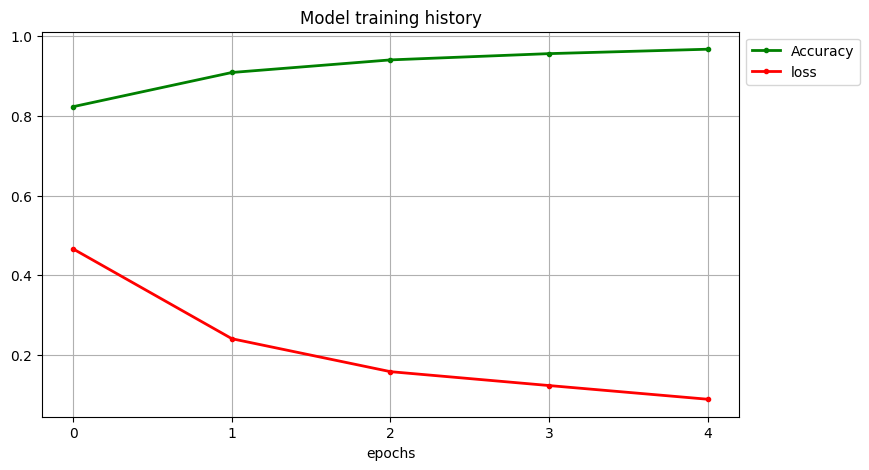

In [31]:
plt.figure(figsize=(9,5))
plt.grid(True)
plt.plot(history.history['accuracy'],'.g-',linewidth=2)
plt.plot(history.history['loss'],'.r-',linewidth=2)
plt.title("Model training history")
plt.xlabel("epochs")
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy','loss'],loc='upper left',bbox_to_anchor=(1,1))
plt.show()

In [32]:
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,auc
import seaborn as sns
from sklearn.preprocessing import label_binarize

test_images = open_images(test_paths)
test_labels_encoded = encode_labels(test_labels)

test_predictions = model.predict(test_images)
print("classification_report: ")
print(classification_report(test_labels_encoded,np.argmax(test_predictions,axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 47s 941ms/step
classification_report: 
              precision    recall  f1-score   support

           0       0.96      0.75      0.84       400
           1       0.92      0.74      0.82       400
           2       0.86      0.99      0.92       400
           3       0.79      0.99      0.88       400

    accuracy                           0.87      1600
   macro avg       0.88      0.87      0.87      1600
weighted avg       0.88      0.87      0.87      1600



conf_matrix: 


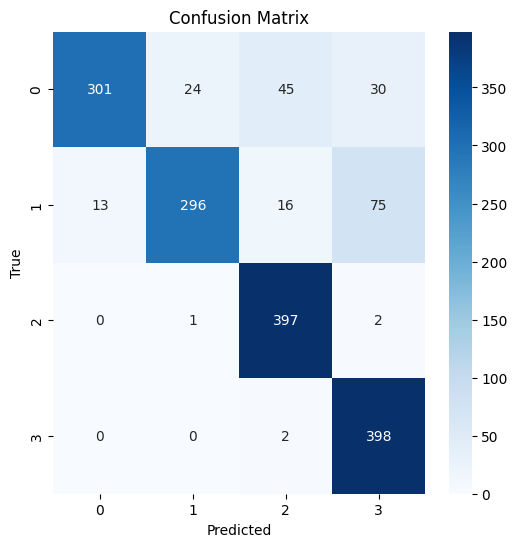

In [33]:
conf_matrix = confusion_matrix(test_labels_encoded,np.argmax(test_predictions,axis=1))
print("conf_matrix: ")
conf_matrix
plt.figure(figsize=(6,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

MRI tumor detection

In [34]:
def detect_and_display(image_path, model):
    try:
        img = load_img(image_path, target_size=(128,128))
        img_array = img_to_array(img)
        img_array = img_array / 255.0   # normalize like training
        img_array = np.expand_dims(img_array, axis=0)

        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions)
        confidence_score = np.max(predictions)

        # Ensure class_labels matches training order
        class_labels = sorted(os.listdir(train_dir))

        if class_labels[predicted_class_index] == 'notumor':
            result = 'No tumor detected'
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        plt.imshow(load_img(image_path))
        plt.axis('off')
        plt.title(f"{result} (confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step


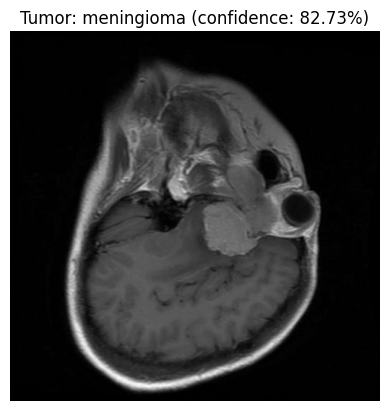

In [35]:
image_path ="C:/Users/Hp/OneDrive/Desktop/Deep learning/MRI images/Testing/meningioma/Te-aug-me_46.jpg"

detect_and_display(image_path,model)